In [9]:
# preliminaries

import os
import imageio
import matplotlib.pyplot as plt

## generic template

#### step 1: make a folder for frames

```
if not os.path.exists('frames'):
    os.makedirs('frames')
```

#### step 2: do something and save frames of each iteration

```
filenames = []
for i in range(n):
    filename = f'frames/frame_{str(i)}.png'
    
    # some type of plotting occurs here
    
    plt.savefig(filename)
    filenames.append(filename)
    plt.close()
```

#### step 3: read them and form gif

```
frames = [imageio.imread(filename) for filename in filenames]
imageio.mimsave("output.gif", frames, fps=2) 
```
fps here meaning "frames per second" (that is, bigger fps => faster gif / smaller fps => slower gif)

#### (optional) step 4: delete frames from folder

```
for filename in filenames:
    os.remove(filename)
```

## basic example

In [104]:
# more preliminaries

import networkx as nx
import random
import numpy as np

In [136]:
# this will be our plotting function

def networkdraw(graph, pos, node_colors):
    nx.draw_networkx_nodes(graph, 
                           pos = pos,
                           node_color = node_colors,
                           node_size = 100,
                          edgecolors = 'black',
                           linewidths = 3)
    nx.draw_networkx_edges(graph,
                           pos = pos,
                           edge_color = [graph[i][j]['color'] for (i,j) in graph.edges()],
                          width = 3)

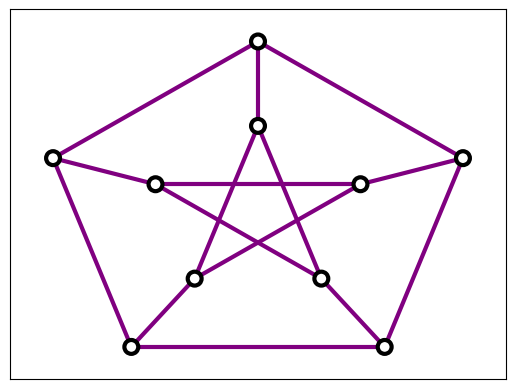

In [137]:
# take the petersen graph

graph = nx.petersen_graph()

# after much trial and error, this makes the petersen graph look nice!

pos = {5: np.array([-2.18556941e-08,  5.00000000e-01]),
 6: np.array([-0.4755283,  0.1545084]),
 7: np.array([-0.29389253, -0.40450856]),
 8: np.array([ 0.29389274, -0.40450841]),
 9: np.array([0.47552821, 0.15450865]),
 0: np.array([-4.37113882e-08,  1.00000000e+00]),
 1: np.array([-0.9510566,  0.3090168]),
 2: np.array([-0.58778506, -0.80901712]),
 3: np.array([ 0.58778548, -0.80901682]),
 4: np.array([0.95105642, 0.3090173 ])}

node_colors = ['white' for i in range(len(graph.nodes()))]

for (i,j) in graph.edges():
    graph[i][j]['color'] = 'purple'

networkdraw(graph, pos, node_colors)

#### step 1: make a folder for frames

In [144]:
if not os.path.exists('frames'):
    os.makedirs('frames')

#### step 2: do something and save frames of each iteration


In [149]:
n = 100
filenames = []
count = 0
for i in range(n):
    
    
    filename = f'frames/frame_{str(count)}.png'
    networkdraw(graph, pos, node_colors)
    plt.savefig(filename)
    filenames.append(filename)
    plt.close()

    count += 1
    future = random.choice(list(graph.neighbors(current)))
    graph[current][future]['color'] = 'teal'
    
    filename = f'frames/frame_{str(count)}.png'
    networkdraw(graph, pos, node_colors)
    plt.savefig(filename)
    filenames.append(filename)
    plt.close()
    
    count += 1
    node_colors[future] = 'yellow'

    filename = f'frames/frame_{str(count)}.png'
    networkdraw(graph, pos, node_colors)
    plt.savefig(filename)
    filenames.append(filename)
    plt.close()
    
    count += 1
    node_colors[current] = 'white'
    node_colors[future] = 'green'
    graph[current][future]['color'] = 'purple'
    
    filename = f'frames/frame_{str(count)}.png'
    networkdraw(graph, pos, node_colors)
    plt.savefig(filename)
    filenames.append(filename)
    plt.close()
    
    count += 1
    current = future

#### step 3: read them and form gif


In [150]:
frames = [imageio.v2.imread(filename) for filename in filenames]
imageio.mimsave("output.gif", frames, fps=4) 

#### (optional) step 4: delete frames from folder


In [147]:
for filename in filenames:
    os.remove(filename)